# Neural Networks - AI-gestuurde PyGame-game

### Activeren van GPU in wsl

In [1]:
# conda activate tfgpu
# jupyter notebook --no-browser --ip=127.0.0.1 --port=8890

In [1]:
import sys, random, joblib
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report

gpus = tf.config.list_physical_devices("GPU")
print("Python:", sys.executable)
print("TensorFlow:", tf.__version__)
print("GPU:", gpus)

if not gpus:
    raise RuntimeError("Geen GPU gevonden. Kies kernel: Python TensorFlow GPU")

for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)

I0000 00:00:1780242403.565158     565 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1780242404.909148     565 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1780242409.797866     565 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


Python: /home/bayra/miniconda3/envs/tfgpu/bin/python
TensorFlow: 2.21.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 3. Game conf

De game blijft bewust klein. Daardoor is de code goed uit te leggen.


In [2]:
# Scherm
W, H = 500, 600
FPS = 30

# Speler
PLAYER_W, PLAYER_H = 50, 25
PLAYER_Y = H - 60
PLAYER_SPEED = 20

# Steen
STONE_SIZE = 30
START_SPEED = 16

# Acties voor speler
LEFT, STAY, RIGHT = 0, 1, 2
ACTIONS = {
    LEFT: "links",
    STAY: "stil",
    RIGHT: "rechts"
}

## 4. Gameklasse

Deze klasse bevat de spelregels. Dezelfde klasse wordt gebruikt voor spelen, testen en AI simulatie

In [3]:
class StoneGame:
    # Simpele game: speler ontwijkt een vallende steen

    def __init__(self, render=False):
        self.render = render

        # PyGame starten als we het scherm willen tonen
        if render:
            import pygame
            pygame.init()
            self.pg = pygame
            self.screen = pygame.display.set_mode((W, H))
            pygame.display.set_caption("AI Stone Dodge")
            self.clock = pygame.time.Clock()

        self.reset()

    def reset(self):
        # Zet de game terug naar beginstand
        self.player_x = W // 2
        self.score = 0
        self.speed = START_SPEED
        self.done = False
        self.new_stone()
        return self.state()

    def new_stone(self):
        # Maakt een nieuwe steen bovenaan het scherm
        self.stone_x = random.randint(0, W - STONE_SIZE)
        self.stone_y = -STONE_SIZE

    def state(self):
        # Input voor het neurale netwerk
        player_center = self.player_x + PLAYER_W / 2
        stone_center = self.stone_x + STONE_SIZE / 2
        distance_x = stone_center - player_center

        return np.array(
            [self.player_x, self.stone_x, self.stone_y, distance_x, self.speed],
            dtype=np.float32
        )

    # Voert een frame van de game uit
    def step(self, action):
        # Speler bewegen
        self.player_x += (action == RIGHT) * PLAYER_SPEED
        self.player_x -= (action == LEFT) * PLAYER_SPEED
        self.player_x = int(np.clip(self.player_x, 0, W - PLAYER_W))

        # Steen laten vallen
        self.stone_y += self.speed

        # Game over bij botsing
        if self.collision():
            self.done = True
            return self.state(), -10, True, {"score": self.score}

        # Punt als steen voorbij de speler valt
        if self.stone_y > H:
            self.score += 1
            self.speed = min(25, START_SPEED + self.score // 5)
            self.new_stone()

        return self.state(), 1, False, {"score": self.score}

    def collision(self):
        # Controleert botsing tussen speler en steen
        return (
            self.player_x < self.stone_x + STONE_SIZE and
            self.player_x + PLAYER_W > self.stone_x and
            PLAYER_Y < self.stone_y + STONE_SIZE and
            PLAYER_Y + PLAYER_H > self.stone_y
        )

    def draw(self):
        # Tekent speler, steen en score
        if not self.render:
            return

        pg = self.pg
        self.screen.fill((25, 25, 35))

        pg.draw.rect(self.screen, (60, 170, 255), (self.player_x, PLAYER_Y, PLAYER_W, PLAYER_H))
        pg.draw.rect(self.screen, (230, 70, 70), (self.stone_x, self.stone_y, STONE_SIZE, STONE_SIZE))

        font = pg.font.SysFont(None, 30)
        score_text = font.render(f"Score: {self.score}", True, (255, 255, 255))
        self.screen.blit(score_text, (10, 10))

        pg.display.flip()
        self.clock.tick(FPS)

    def close(self):
        # Sluit PyGame
        if self.render:
            self.pg.quit()

## 5. Trainingsdata verzamelen

Voer `collect_data()` uit om zelf data te verzamelen.
De data wordt opgeslagen in `training_data.csv`

Besturing:
- pijl links = links
- pijl rechts = rechts
- geen toets = stil


In [4]:
def collect_data(path="training_data.csv"):
    # Laat de speler spelen en slaat trainingsdata op
    import pygame

    game = StoneGame(render=True)
    rows = []

    while True:
        action = STAY

        # Stoppen als het venster wordt gesloten
        for event in pygame.event.get():
            if event.type == pygame.QUIT:
                game.close()
                return save_data(rows, path)

        # Actie bepalen met toetsenbord
        keys = pygame.key.get_pressed()
        if keys[pygame.K_LEFT]:
            action = LEFT
        elif keys[pygame.K_RIGHT]:
            action = RIGHT

        # State + actie opslaan
        rows.append([*game.state(), action])

        # Game een frame verder zetten
        _, _, done, info = game.step(action)
        game.draw()

        if done:
            print("Game over. Score:", info["score"])
            game.reset()


def save_data(rows, path):
    # Slaat nieuwe data op en voegt oude data toe als die bestaat
    columns = ["player_x", "stone_x", "stone_y", "distance_x", "speed", "action"]
    df = pd.DataFrame(rows, columns=columns)

    if Path(path).exists():
        old_df = pd.read_csv(path)
        df = pd.concat([old_df, df], ignore_index=True)

    df.to_csv(path, index=False)
    print("Opgeslagen:", path, "| rijen:", len(df))
    return df

In [5]:
# Gebruik deze regel om echte data te verzamelen
df = collect_data()


pygame 2.6.1 (SDL 2.28.4, Python 3.12.13)
Hello from the pygame community. https://www.pygame.org/contribute.html
Game over. Score: 0
Game over. Score: 54
Opgeslagen: training_data.csv | rijen: 10837


## 6. Demo data

Voor snel testen maakt de notebook automatisch voorbeelddata.
Voor de echte inlevering is eigen gespeelde data beter.


In [6]:
def choose_demo_action(state):
    # Simpele strategie voor demo data
    _, _, stone_y, distance_x, _ = state

    # Pas ontwijken als de steen dichtbij genoeg is.
    if stone_y < H * 0.45:
        return STAY

    if distance_x < -15:
        return RIGHT
    if distance_x > 15:
        return LEFT

    return random.choice([LEFT, RIGHT])


def make_demo_data(path="training_data.csv", n=5000):
    # Maakt voorbeeld data zonder zelf te spelen
    game = StoneGame()
    rows = []

    for _ in range(n):
        state = game.state()
        action = choose_demo_action(state)

        rows.append([*state, action])

        _, _, done, _ = game.step(action)
        if done:
            game.reset()

    columns = ["player_x", "stone_x", "stone_y", "distance_x", "speed", "action"]
    df = pd.DataFrame(rows, columns=columns)
    df.to_csv(path, index=False)

    return df


# Gebruik bestaande data, anders maak demo-data.
data_path = Path("training_data.csv")
df = pd.read_csv(data_path) if data_path.exists() else make_demo_data(data_path)

df.head()

,player_x,stone_x,stone_y,distance_x,speed,action
0,250.0,414.0,-30.0,154.0,5.0,1
1,250.0,414.0,-25.0,154.0,5.0,1
2,250.0,414.0,-20.0,154.0,5.0,1
3,250.0,414.0,-15.0,154.0,5.0,1
4,250.0,414.0,-10.0,154.0,5.0,1


## 7. Data bekijken


In [7]:
# Trainingsdata laden
data_path = Path("training_data.csv")
df = pd.read_csv(data_path)

# Actienummers omzetten naar tekst
df["actie"] = df["action"].map(ACTIONS)

# Snelle controle van de data
print("Aantal datarijen:", len(df))
display(df.head())
display(df["actie"].value_counts())

Aantal datarijen: 10837


,player_x,stone_x,stone_y,distance_x,speed,action,actie
0,250.0,414.0,-30.0,154.0,5.0,1,stil
1,250.0,414.0,-25.0,154.0,5.0,1,stil
2,250.0,414.0,-20.0,154.0,5.0,1,stil
3,250.0,414.0,-15.0,154.0,5.0,1,stil
4,250.0,414.0,-10.0,154.0,5.0,1,stil


actie
stil      6943
links     2735
rechts    1159
Name: count, dtype: int64

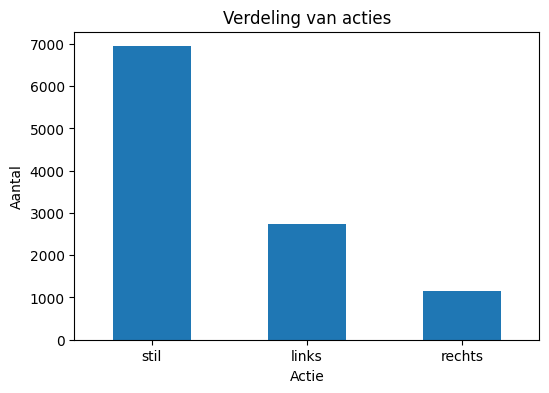

In [8]:
# Tel hoe vaak elke actie voorkomt en toon dit als staafdiagram
actie_counts = df["actie"].value_counts()

actie_counts.plot(kind="bar", figsize=(6, 4))

plt.title("Verdeling van acties")
plt.xlabel("Actie")
plt.ylabel("Aantal")
plt.xticks(rotation=0)
plt.show()

## 8. Data voorbereiden

De data wordt gesplitst in train- en testdata. Daarna worden de inputwaarden geschaald.


In [9]:
# Inputfeatures en target bepalen
features = ["player_x", "stone_x", "stone_y", "distance_x", "speed"]

X = df[features]      # input voor het model
y = df["action"]      # juiste actie: links, stil of rechts

# Data splitsen in train- en testset
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Features schalen voor stabielere training
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (8669, 5)
Test: (2168, 5)


## 9. Model maken

Het model heeft 5 inputwaarden en 3 outputklassen.


In [10]:
def build_model(hidden=(32, 16), dropout=0.0):
    """Bouwt een neuraal netwerk voor 3 acties: links, stil, rechts."""

    model = keras.Sequential([
        layers.Input(shape=(5,))  # 5 inputfeatures
    ])

    # Hidden layers toevoegen
    for units in hidden:
        model.add(layers.Dense(units, activation="relu"))

        # Dropout voorkomt deels overfitting
        if dropout:
            model.add(layers.Dropout(dropout))

    # Outputlaag: 3 acties
    model.add(layers.Dense(3, activation="softmax"))

    # Model instellen voor classificatie
    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

## 10. Testen

Er zijn 30 testen toegevoegd. Deze controleren de game, data, scaler, model en GPU.


In [11]:
def run_tests():
    """Controleert of game, data, scaler, model en GPU werken."""
    print("Tests gestart...")

    game = StoneGame()

    # 1 t/m 6: startwaarden controleren
    assert game.state().shape == (5,), "State moet 5 waarden hebben"
    assert game.state().dtype == np.float32, "State moet float32 zijn"
    assert 0 <= game.player_x <= W - PLAYER_W, "Speler start buiten scherm"
    assert 0 <= game.stone_x <= W - STONE_SIZE, "Steen start buiten scherm"
    assert game.score == 0 and not game.done, "Score/done start verkeerd"
    assert game.speed == START_SPEED, "Startsnelheid klopt niet"

    # 7 t/m 10: beweging en schermgrenzen
    old_x = game.player_x
    game.step(LEFT)
    assert game.player_x < old_x, "Links bewegen werkt niet"

    game.step(RIGHT)
    assert game.player_x >= old_x, "Rechts bewegen werkt niet"

    game.player_x = 0
    game.step(LEFT)
    assert game.player_x == 0, "Speler mag niet links uit beeld"

    game.player_x = W - PLAYER_W
    game.step(RIGHT)
    assert game.player_x == W - PLAYER_W, "Speler mag niet rechts uit beeld"

    # 11 t/m 13: steen, score en botsing
    game = StoneGame()
    old_y = game.stone_y
    game.step(STAY)
    assert game.stone_y > old_y, "Steen valt niet"

    game.stone_y = H + 1
    game.step(STAY)
    assert game.score == 1, "Score moet omhoog als steen voorbij is"

    game.player_x, game.stone_x, game.stone_y = 200, 210, PLAYER_Y
    assert game.collision(), "Botsing wordt niet herkend"

    # 14: demo-data controleren
    test_df = make_demo_data("test_training_data.csv", n=300)
    assert len(test_df) == 300, "Aantal datarijen klopt niet"
    assert set(test_df["action"]).issubset({LEFT, STAY, RIGHT}), "Ongeldige actie in data"

    # 15: scaler, model en GPU controleren
    X_tmp = test_df[features].values
    X_scaled = StandardScaler().fit_transform(X_tmp)

    assert X_scaled.shape == (300, 5), "Scaler-output klopt niet"
    assert build_model((8,)).output_shape == (None, 3), "Model-output moet 3 acties zijn"
    assert tf.config.list_physical_devices("GPU"), "GPU niet gevonden"

    print("Alle testen zijn geslaagd.")


run_tests()

Tests gestart...


I0000 00:00:1780242552.839350     565 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 3536 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


Alle testen zijn geslaagd.


## 11. Experimenten trainen


In [12]:
# Check of GPU beschikbaar is
gpus = tf.config.list_physical_devices("GPU")
print("GPU:", gpus if gpus else "Geen GPU gevonden")

# Modellen die we willen testen
experiments = [
    ("Klein",   (16,),         0.0, 10),
    ("Middel",  (32, 16),      0.0, 15),
    ("Dropout", (64, 32),      0.2, 20),
    ("Dieper",  (64, 32, 16),  0.2, 20),
]

results, models = [], {}

for name, hidden, dropout, epochs in experiments:
    print("Training:", name)

    # Model bouwen en trainen
    model = build_model(hidden=hidden, dropout=dropout)
    model.fit(X_train, y_train, validation_split=0.2, epochs=epochs, batch_size=32, verbose=0)

    # Resultaten meten
    train_loss, train_acc = model.evaluate(X_train, y_train, verbose=0)
    test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)

    results.append([
        name, str(hidden), dropout, epochs,
        round(train_acc, 4), round(test_acc, 4),
        round(train_loss, 4), round(test_loss, 4)
    ])

    models[name] = model

# Resultaten tonen in tabel
results_df = pd.DataFrame(results, columns=[
    "Experiment", "Lagen", "Dropout", "Epochs",
    "Train accuracy", "Test accuracy", "Train loss", "Test loss"
])

results_df

GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Training: Klein


I0000 00:00:1780242560.403803     666 service.cc:153] XLA service 0x7e69a4042310 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1780242560.403870     666 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 4050 Laptop GPU, Compute Capability 8.9 (Driver: 13.3.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.22.0)
I0000 00:00:1780242560.513709     666 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1780242560.755497     666 cuda_dnn.cc:461] Loaded cuDNN version 92200
I0000 00:00:1780242560.775398     666 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1007__.12
I0000 00:00:1780242563.461308     666 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
I0000 00:00:1780242564.665174     666 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_100

Training: Middel


I0000 00:00:1780242589.202148     667 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_15080__.13
I0000 00:00:1780242592.682486     665 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_15080__.13


Training: Dropout


I0000 00:00:1780242625.553984     665 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_34916__.15
I0000 00:00:1780242630.619271     665 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_34916__.15


Training: Dieper


I0000 00:00:1780242672.372217     664 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_60690__.17
I0000 00:00:1780242677.160966     664 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_60690__.17


,Experiment,Lagen,Dropout,Epochs,Train accuracy,Test accuracy,Train loss,Test loss
0,Klein,"(16,)",0.0,10,0.8754,0.8805,0.3510,0.3291
1,Middel,"(32, 16)",0.0,15,0.9099,0.9174,0.2471,0.2340
2,Dropout,"(64, 32)",0.2,20,0.9103,0.9142,0.2229,0.2155
3,Dieper,"(64, 32, 16)",0.2,20,0.9094,0.9156,0.2234,0.2161


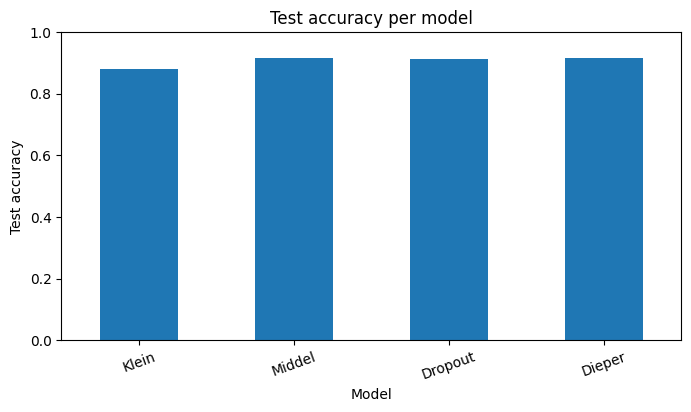

In [13]:
# Test accuracy per model tonen
results_df.plot(
    x="Experiment",
    y="Test accuracy",
    kind="bar",
    figsize=(8, 4),
    ylim=(0, 1),
    legend=False
)

plt.title("Test accuracy per model")
plt.xlabel("Model")
plt.ylabel("Test accuracy")
plt.xticks(rotation=20)
plt.show()

In [14]:
# Beste model kiezen op basis van test accuracy
best_name = results_df.loc[results_df["Test accuracy"].idxmax(), "Experiment"]
best_model = models[best_name]

# Model en scaler opslaan
best_model.save("best_stone_ai.keras")
joblib.dump(scaler, "stone_scaler.pkl")

print(f"Beste model: {best_name}")
print("Model en scaler zijn opgeslagen.")

Beste model: Middel
Model en scaler zijn opgeslagen.


## 12. Model beoordelen

Hier zie je hoe goed het model links, stil en rechts voorspelt.


In [15]:
# Voorspel acties op de testset
pred = best_model.predict(X_test, verbose=0).argmax(axis=1)

# Toon prestaties per actie
print(classification_report(
    y_test,
    pred,
    target_names=["links", "stil", "rechts"]
))

              precision    recall  f1-score   support

       links       0.91      0.87      0.89       547
        stil       0.96      0.96      0.96      1389
      rechts       0.70      0.75      0.72       232

    accuracy                           0.92      2168
   macro avg       0.86      0.86      0.86      2168
weighted avg       0.92      0.92      0.92      2168



## 13. AI koppelen aan de game


In [16]:
def predict_action(model, scaler, state):
    # AI kiest de actie met de hoogste voorspelde kans
    state = scaler.transform([state])
    probs = model(state, training=False).numpy()[0]
    return int(probs.argmax())


def play_ai(model_path="best_stone_ai_gpu.keras", scaler_path="stone_scaler_gpu.pkl"):
    # Laat het getrainde model de game spelen
    import pygame

    model = keras.models.load_model(model_path)
    scaler = joblib.load(scaler_path)
    game = StoneGame(render=True)

    action = STAY
    frame = 0

    while True:
        # Venster sluiten = stoppen
        for event in pygame.event.get():
            if event.type == pygame.QUIT:
                game.close()
                return

        # Niet elke frame voorspellen, dat maakt de game sneller
        if frame % 3 == 0:
            action = predict_action(model, scaler, game.state())

        _, _, done, info = game.step(action)
        game.draw()
        frame += 1

        if done:
            print("AI score:", info["score"])
            game.reset()

In [17]:
# Voer deze cel uit om de AI te laten spelen.
play_ai()


AI score: 17
AI score: 2
AI score: 4
AI score: 4
AI score: 3
AI score: 2
AI score: 8
AI score: 1
AI score: 13
AI score: 19
AI score: 1
AI score: 12
AI score: 4
AI score: 1
AI score: 7
AI score: 10
AI score: 2
AI score: 1
AI score: 0
AI score: 1
AI score: 1
AI score: 0
AI score: 10
AI score: 2
AI score: 7
AI score: 9
AI score: 7
AI score: 1
AI score: 2
AI score: 6
AI score: 8
AI score: 9


## 14. AI vergelijken met random speler

Deze evaluatie draait zonder PyGame-scherm en is daardoor sneller.


In [18]:
def evaluate(policy, games=20, max_steps=3000):
    # Test een speler meerdere potjes en geeft de gemiddelde score
    scores = []

    for _ in range(games):
        game = StoneGame()

        for _ in range(max_steps):
            _, _, done, _ = game.step(policy(game.state()))
            if done:
                break

        scores.append(game.score)

    return round(np.mean(scores), 2)


# Random speler vergelijken met AI
compare_df = pd.DataFrame({
    "Speler": ["Random", "AI-model"],
    "Gemiddelde score": [
        evaluate(lambda state: random.choice([LEFT, STAY, RIGHT])),
        evaluate(lambda state: predict_action(best_model, scaler, state))
    ]
})

compare_df

/home/bayra/miniconda3/envs/tfgpu/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/home/bayra/miniconda3/envs/tfgpu/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/home/bayra/miniconda3/envs/tfgpu/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/home/bayra/miniconda3/envs/tfgpu/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/home/bayra/miniconda3/envs/tfgpu/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, b

,Speler,Gemiddelde score
0,Random,3.65
1,AI-model,6.30


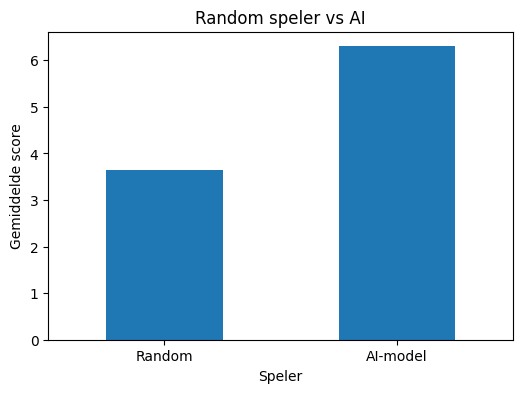

In [19]:
# Vergelijk gemiddelde score van random speler en AI
compare_df.plot.bar(
    x="Speler",
    y="Gemiddelde score",
    figsize=(6, 4),
    legend=False
)

plt.title("Random speler vs AI")
plt.ylabel("Gemiddelde score")
plt.xticks(rotation=0)
plt.show()

### Reflectie
De kwaliteit van het model hangt vooral af van de trainingsdata. Als de speler weinig of slechte data verzamelt, leert het model minder goed.
Een verbetering is om meer eigen data te verzamelen of later reinforcement learning te gebruiken.